# Mean and St.Dev. 

In [2]:
import pandas as pd
import numpy as np
import re

# Leggi il file CSV
df = pd.read_csv('/Users/edoardoconti/Downloads/results_ordinal_paper/results_pretrained.csv')

# Estrai il tipo di esperimento da 'experiment'
df['experiment_type'] = df['experiment'].apply(lambda x: re.search(r'_(obd|clm|resnet18|resnetQWK|cnnregstn)', x).group(1) if re.search(r'_(obd|clm|resnet18|resnetQWK|cnnregstn)', x) else 'unknown')

# rename
df['experiment_type'] = df['experiment_type'].replace('resnet18', 'resnet18 CCE')
df['experiment_type'] = df['experiment_type'].replace('resnetQWK', 'resnet18 QWK')

# Definisci le metriche da calcolare
metrics = ["ccr", "f1", "acc_1off", "acc_2off", "qwk", "spearman", "ms", "mae", "rmse"]

# Funzione per calcolare media e deviazione standard delle metriche
def calculate_stats(experiment_df):
    mean_values = experiment_df[metrics].mean()
    std_values = experiment_df[metrics].std()
    return mean_values, std_values

# Calcola media e deviazione standard per ogni tipo di esperimento
experiment_types = df['experiment_type'].unique()

# Stampa le medie e le deviazioni standard per ogni tipo di esperimento
for exp_type in experiment_types:
    exp_df = df[df['experiment_type'] == exp_type]
    mean_values, std_values = calculate_stats(exp_df)
    
    print(f"\nExperiment Type: {exp_type}")
    print("Mean Values:")
    print(mean_values)
    print("\nStandard Deviation Values:")
    print(std_values)


Experiment Type: cnnregstn
Mean Values:
ccr         0.614413
f1          0.620733
acc_1off    0.956733
acc_2off    0.996940
qwk         0.697020
spearman    0.719933
ms          0.381687
mae         0.442833
rmse        0.714200
dtype: float64

Standard Deviation Values:
ccr         0.041472
f1          0.035720
acc_1off    0.015307
acc_2off    0.003721
qwk         0.056086
spearman    0.040231
ms          0.112824
mae         0.066571
rmse        0.065627
dtype: float64

Experiment Type: resnet18 CCE
Mean Values:
ccr         0.570320
f1          0.564193
acc_1off    0.940400
acc_2off    0.987780
qwk         0.650133
spearman    0.670867
ms          0.326507
mae         0.503373
rmse        0.812167
dtype: float64

Standard Deviation Values:
ccr         0.059951
f1          0.065388
acc_1off    0.025927
acc_2off    0.023329
qwk         0.099990
spearman    0.093573
ms          0.105557
mae         0.083025
rmse        0.112079
dtype: float64

Experiment Type: resnet18 QWK
Mean Values:

# Boxplot

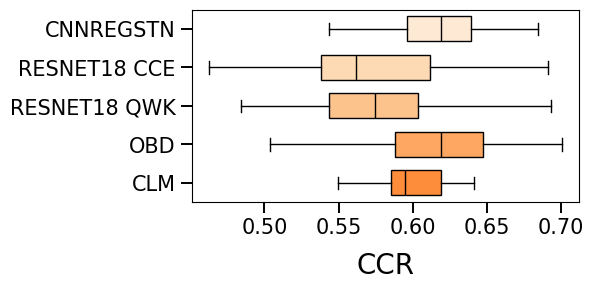

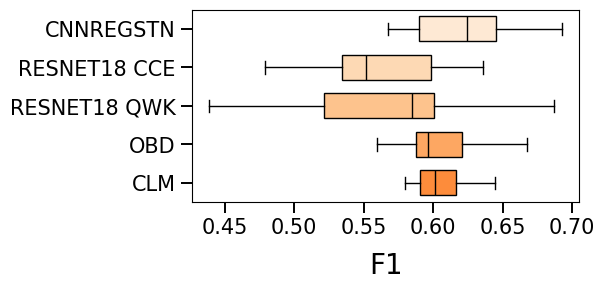

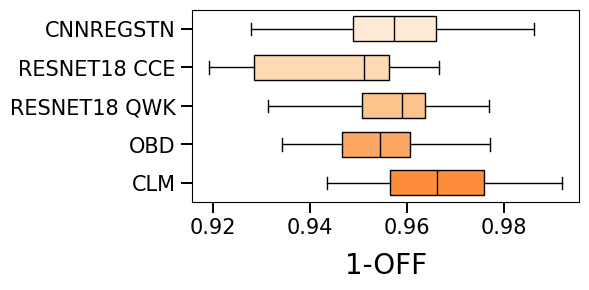

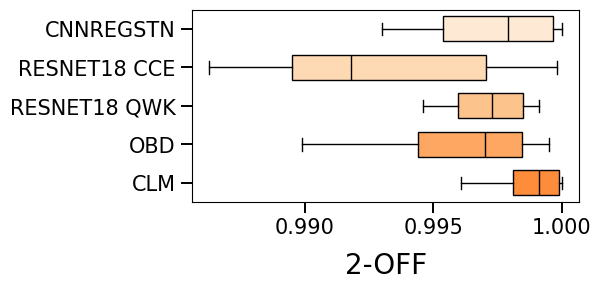

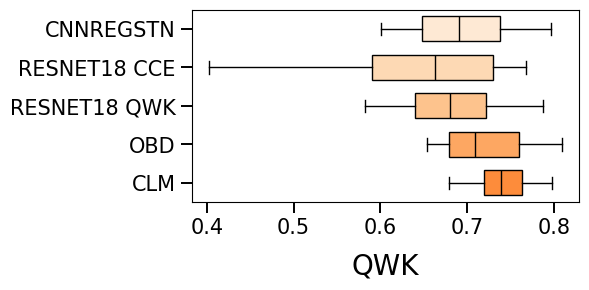

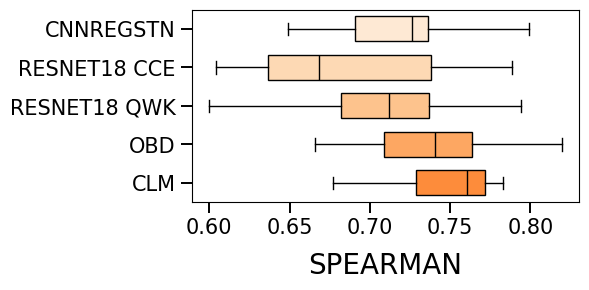

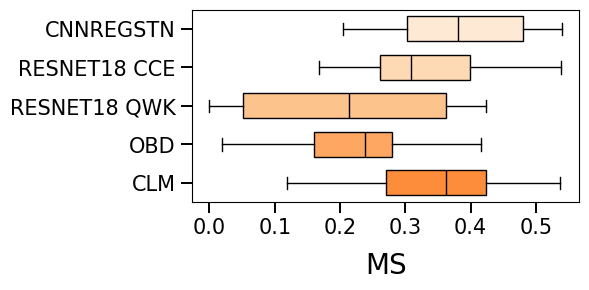

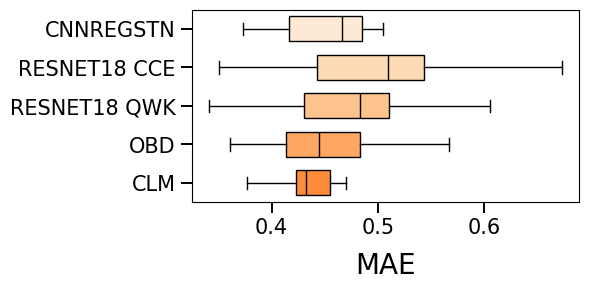

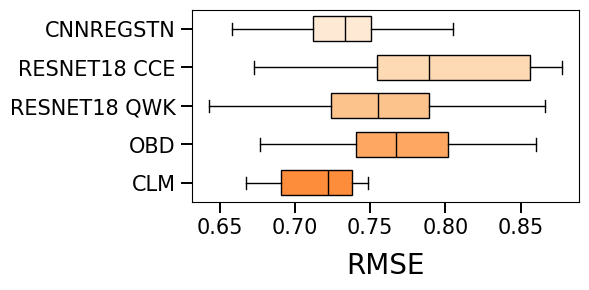

In [9]:
import os
import matplotlib.pyplot as plt

# Percorso della cartella in cui salvare i boxplot
save_folder = '/Users/edoardoconti/Downloads/results_ordinal_paper/materiale_overleaf/boxplots/new'  
os.makedirs(save_folder, exist_ok=True)

for metric in metrics:
    plt.figure(figsize=(5, 2.5)) 
    positions = np.arange(len(experiment_types))
    positions = positions[::-1] #reverse

    medianprops = dict(linestyle='-', color='black')
    
    # Creazione del boxplot con colori
    box_plot = plt.boxplot([df[df['experiment_type'] == exp_type][metric] for exp_type in experiment_types], 
                           positions=positions, 
                           labels=[exp_type.upper() for exp_type in experiment_types],  # Rende maiuscole le etichette
                           showfliers=False,
                           vert=False,
                           widths=0.65,
                           patch_artist=True,
                           medianprops=medianprops
                           )
    
    # Specifica i colori e le gradazioni
    #colors = plt.cm.YlGn(np.linspace(0.1, 0.5, len(experiment_types)))
    colors = plt.cm.Oranges(np.linspace(0.1, 0.5, len(experiment_types)))
    
    # Assegna colori ai boxplot
    for i, box in enumerate(box_plot['boxes']):
        box.set_facecolor(colors[i])

    # Get the metric title, or use the uppercased metric if not in the dictionary
    plt_title = {'ACC_1OFF': '1-OFF', 'ACC_2OFF': '2-OFF', 'F1': 'F1'}.get(metric.upper(), metric.upper())
    plt.xlabel(plt_title, fontsize=20, labelpad=10)  

    # Modifica la dimensione del font per le etichette degli assi
    plt.tick_params(axis='both', labelsize=15, direction='out', length=8, width=1.4)

    plt.show()

    # Costruisci il nome del file e salva l'immagine
    # file_name = f'{save_folder}/{metric.upper()}.png'
    # plt.savefig(file_name, bbox_inches='tight') 
    # plt.close() 

    # print(f'Salvato: {file_name}')

# Confusion Matrix

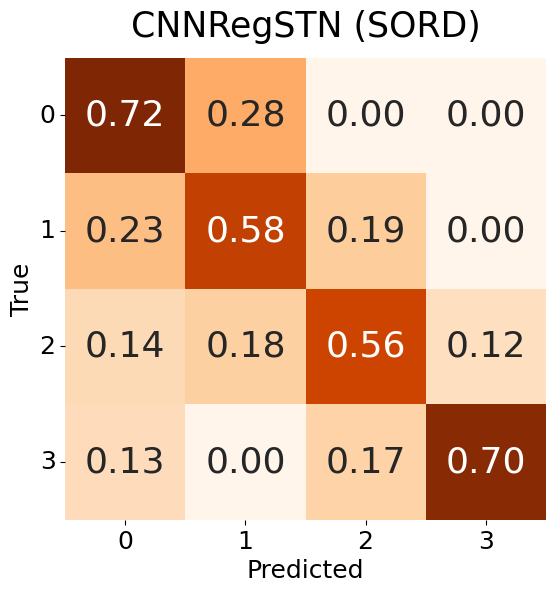

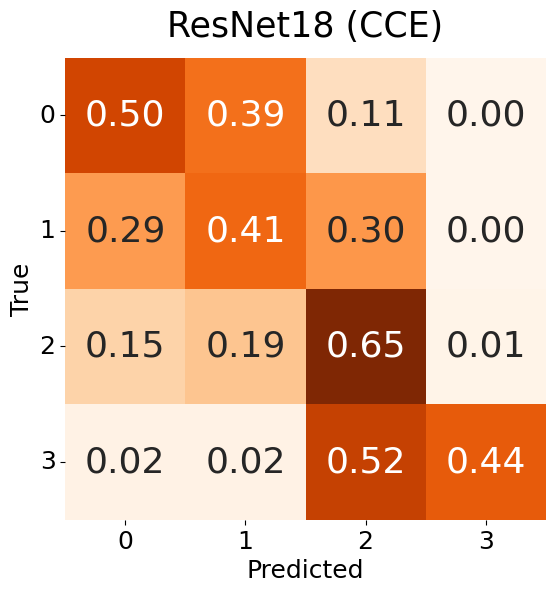

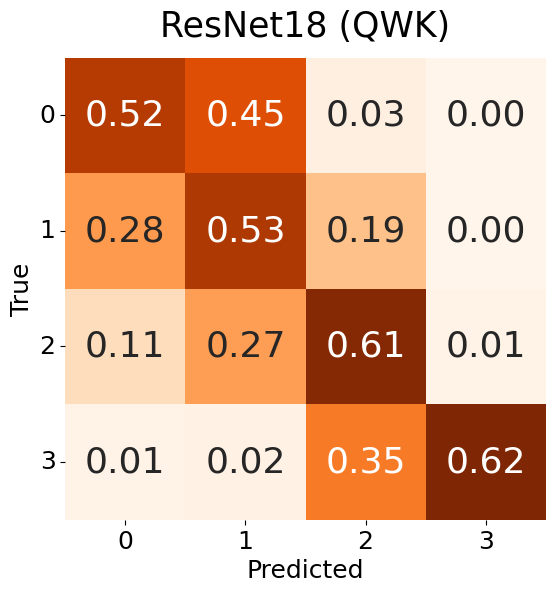

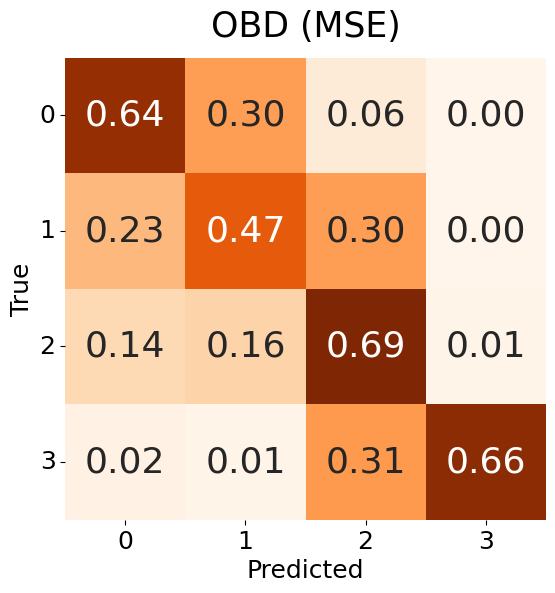

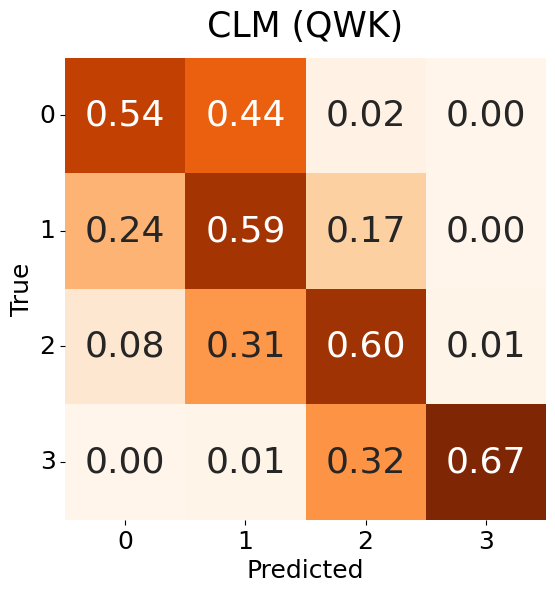

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, title='Confusion matrix', cmap='Oranges', cbar=False):
    plt.figure(figsize=(8, 6)) if cbar else plt.figure(figsize=(6.2, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap, cbar=cbar, annot_kws={"size": 26})
    plt.title(title, size=25, pad=15)
    plt.xlabel('Predicted', size=18)
    plt.ylabel('True', size=18)
    plt.xticks(np.arange(cm.shape[1]) + 0.5, range(cm.shape[1]), fontsize=18)
    plt.yticks(np.arange(cm.shape[0]) + 0.5, range(cm.shape[0]), fontsize=18, rotation=0)
    plt.show()

def plot_multiple_confusion_matrices(cms):
    for title, cm in cms:
        plot_confusion_matrix(cm, title=title)


# results from specific fold and split
cm_cnnregstn_sord = ["CNNRegSTN (SORD)", np.array([[0.72, 0.28, 0.00, 0.00],
                                             [0.23, 0.58, 0.19, 0.00],
                                             [0.14, 0.18, 0.56, 0.12],
                                             [0.13, 0.00, 0.17, 0.70]])]

cm_resnet_cce = ["ResNet18 (CCE)", np.array([[0.50, 0.39, 0.11, 0.00],
                                             [0.29, 0.41, 0.30, 0.00],
                                             [0.15, 0.19, 0.65, 0.01],
                                             [0.02, 0.02, 0.52, 0.44]])]

cm_resnet_qwk = ["ResNet18 (QWK)", np.array([[0.52, 0.45, 0.03, 0.00],
                                             [0.28, 0.53, 0.19, 0.00],
                                             [0.11, 0.27, 0.61, 0.01],
                                             [0.01, 0.02, 0.35, 0.62]])]

cm_obd_mse = ["OBD (MSE)", np.array([[0.64, 0.30, 0.06, 0.00],
                                     [0.23, 0.47, 0.30, 0.00],
                                     [0.14, 0.16, 0.69, 0.01],
                                     [0.02, 0.01, 0.31, 0.66]])]

cm_clm_qwk = ["CLM (QWK)", np.array([[0.54, 0.44, 0.02, 0.00],
                                     [0.24, 0.59, 0.17, 0.00],
                                     [0.08, 0.31, 0.60, 0.01],
                                     [0.00, 0.01, 0.32, 0.67]])]

# Lista delle matrici di confusione con i rispettivi titoli
cms = [cm_cnnregstn_sord, cm_resnet_cce, cm_resnet_qwk, cm_obd_mse, cm_clm_qwk]

# Chiamata alla funzione per stampare tutte le matrici
plot_multiple_confusion_matrices(cms)

### F1-score check test

In [ ]:
import numpy as np

# Estrazione della matrice di confusione
_, cm = cm_cnnregstn_sord

# Calcolo delle metriche
true_positives = np.diag(cm)
false_positives = cm.sum(axis=0) - true_positives
false_negatives = cm.sum(axis=1) - true_positives
true_negatives = cm.sum() - (true_positives + false_positives + false_negatives)

# Calcolo della precisione e richiamo
precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

# Calcolo dell'F1 Score
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_weighted = np.sum(f1_scores * (true_positives + false_negatives)) / np.sum(cm)

print(f"F1 Score: {f1_weighted:.2f}")

# Statistical analysis

In [ ]:
%pip install scikit-posthocs --quiet

In [3]:
import pandas as pd
import re

# Funzione per estrarre il nome del modello usando regex
def extract_model(experiment):
    match = re.search(r'_(cnnregstn|resnet18|resnetQWK|obd|clm)_', experiment)
    return match.group(1) if match else None

# Funzione per estrarre fold e split
def extract_fold_split(experiment):
    match = re.search(r'fold(\d+)_split(\d+)', experiment)
    return (int(match.group(1)), int(match.group(2))) if match else (None, None)

def rank_ascending(metric):
    return metric in {'mae', 'rmse'}

# parametri 
file_path = '/Users/edoardoconti/Downloads/results_ordinal_paper/results_pretrained.csv' # csv con i risultati
alpha = 0.05
metric = 'qwk'

# lettura csv risultati
df = pd.read_csv(file_path)

# Applicare la funzione di estrazione del modello alla colonna "experiment"
df['measures'] = df['experiment'].apply(extract_model)

# Applicare la funzione di estrazione di fold e split alla colonna "experiment"
df[['fold', 'split']] = df['experiment'].apply(lambda x: pd.Series(extract_fold_split(x)))

# Creare un DataFrame pivot con i modelli come colonne, fold e split come indice, e QWK come valori
df_measures = df.pivot_table(index=['fold', 'split'], columns='measures', values=metric)

# Rimuovere le colonne fold e split
df_measures.reset_index(drop=True, inplace=True)

# Mostrare il DataFrame risultante
df_measures.head()

measures,clm,cnnregstn,obd,resnet18,resnetQWK
0,0.7564,0.7969,0.7394,0.5929,0.7103
1,0.7982,0.7411,0.8091,0.5883,0.6619
2,0.7690,0.6906,0.7897,0.7684,0.6301
3,0.7390,0.7351,0.7069,0.5588,0.5826
4,0.7215,0.6322,0.6557,0.6227,0.6236


In [22]:
# Creare la ranking table
df_rank = df_measures.rank(axis=1, method='min', ascending=rank_ascending(metric))

# Aggiungere una riga con la media dei rank per ciascun modello
df_rank.loc['average'] = df_rank.mean()

# Mostrare la ranking table risultante
#df_rank.tail()
df_rank

measures,clm,cnnregstn,obd,resnet18,resnetQWK
0,2.000000,1.0,3.000000,5.000000,4.000000
1,2.000000,3.0,1.000000,5.000000,4.000000
2,2.000000,4.0,1.000000,3.000000,5.000000
3,1.000000,2.0,3.000000,5.000000,4.000000
4,1.000000,3.0,2.000000,5.000000,4.000000
5,1.000000,4.0,2.000000,5.000000,3.000000
6,2.000000,1.0,4.000000,3.000000,5.000000
7,4.000000,5.0,3.000000,1.000000,2.000000
8,1.000000,2.0,4.000000,5.000000,3.000000
9,3.000000,5.0,4.000000,1.000000,2.000000


In [23]:
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# Convertire il DataFrame in array per il test di Friedman
array_measures = [df_measures[col].values for col in df_measures.columns]

# settare valore di alpha
alpha = 0.05

# Test di Friedman
stat, p_value = friedmanchisquare(*array_measures)

print(f"\033[1mSettings:\033[0m")
print(f"alpha = {alpha}")
print(f"metric evaluated = {metric}\n")

print(f"\033[1mFriedman test results:\033[0m")
print(f"Statistic = {stat}")
print(f"p-value = {p_value}\n")

# Test di Nemenyi (se p-value del Friedman test è significativo)
print(f"\033[1mNemenyi post-hoc test results:\033[0m")
if p_value < alpha:
    # scikit_posthocs nemenyi test
    nemenyi_results = sp.posthoc_nemenyi_friedman(df_measures.values)
    print(f"{nemenyi_results}\n")
    
    # individuare dalla tabella del test post hoc nemenyi se ci sono confronti significativi
    significant_results = [
        (df_measures.columns[i], df_measures.columns[j], nemenyi_results.iloc[i, j],
        df_rank.columns[i] if df_rank.loc['average', df_measures.columns[i]] < df_rank.loc['average', df_measures.columns[j]] else df_rank.columns[j])
        for i in range(nemenyi_results.shape[0]) 
        for j in range(i + 1, nemenyi_results.shape[1]) 
        if nemenyi_results.iloc[i, j] < alpha
    ]
    
    if significant_results:
        for model1, model2, p_value, better_model in significant_results:
            print(f"Significant comparison between {model1.upper()} e {model2.upper()} with p-value = {p_value:.5f} (best model: {better_model.upper()}).")
    else:
        print(f"No significant comparison between models.")
else:
    print("There are no significant differences between the groups according to the Friedman test.")

Settings:
alpha = 0.05
metric evaluated = qwk

Friedman test results:
Statistic = 12.106666666666683
p-value = 0.016575443020844075

Nemenyi post-hoc test results:
          0         1         2         3         4
0  1.000000  0.181763  0.684493  0.022507  0.044342
1  0.181763  1.000000  0.881091  0.900000  0.900000
2  0.684493  0.881091  1.000000  0.415786  0.553426
3  0.022507  0.900000  0.415786  1.000000  0.900000
4  0.044342  0.900000  0.553426  0.900000  1.000000

Significant comparison between CLM e RESNET18 with p-value = 0.02251 (best model: CLM).
Significant comparison between CLM e RESNETQWK with p-value = 0.04434 (best model: CLM).


### Manual computation of tests

In [39]:
from scipy.stats import f

# Calcolare Q
n = len(df_rank) - 1  # il numero di righe è 15
k = len(df_rank.columns)  # il numero di modelli è 5
mean_ranks = df_rank.loc['average'].values

# chi-square
Q = (12 * n) / (k * (k + 1)) * np.sum((mean_ranks - (k + 1) / 2) ** 2)
# chi_squared_F = (12 * n) / (k * (k + 1)) * (np.sum(mean_ranks ** 2) - (k * (k + 1) ** 2) / 4) # formulazione alternativa a Q
FF = ((n - 1) * Q) / ((n * (k - 1)) - Q)

# Definire i gradi di libertà
dfn = k - 1  # Gradi di libertà del numeratore
dfd = (k-1) * (n-1)  # Gradi di libertà del denominatore

# Livello di significatività
alpha = 0.05

# Calcolare il valore critico F
F_critical = f.ppf(1 - alpha, dfn, dfd)

print(f"chi-square_F = {Q}")
print(f"F_F = {FF}\n")
print(f"Critic value F: {F_critical}\n")
print(f"Statistically significant: {FF > F_critical}")

chi-square_F = 12.106666666666666
F_F = 3.5389755011135855

Critic value F: 2.5365793916182766

Statistically significant: True


In [40]:
import numpy as np

q_alpha = 2.728
CD = q_alpha * np.sqrt((k * (k + 1)) / (6 * n))

# Mostrare il valore critico per il test di Nemenyi
print(f'Critical value for Nemenyi test: {CD:.4f}\n')

# Estrarre le mean_rank
mean_ranks = df_rank.loc['average'].values

# Calcolare tutte le differenze tra ogni coppia di mean_rank
differences = []
for i in range(k):
    for j in range(i + 1, k):
        diff = abs(mean_ranks[i] - mean_ranks[j])
        differences.append((df_rank.columns[i], df_rank.columns[j], diff, diff > CD))

# Mostrare le differenze e il confronto con il valore critico
for model1, model2, diff, significant in differences:
    result = "Significant" if significant else "Not significant"
    print(f'{model1} vs {model2}: {diff:.4f} ({result})')

Critical value for Nemenyi test: 1.5750

clm vs cnnregstn: 1.2667 (Not significant)
clm vs obd: 0.7333 (Not significant)
clm vs resnet18: 1.7333 (Significant)
clm vs resnetQWK: 1.6000 (Significant)
cnnregstn vs obd: 0.5333 (Not significant)
cnnregstn vs resnet18: 0.4667 (Not significant)
cnnregstn vs resnetQWK: 0.3333 (Not significant)
obd vs resnet18: 1.0000 (Not significant)
obd vs resnetQWK: 0.8667 (Not significant)
resnet18 vs resnetQWK: 0.1333 (Not significant)


# Samples images evaluation

In [24]:
import os
import json
import pandas as pd
import numpy as np
import re
from random import sample

# Funzione per trovare il file predictions.json
def find_predictions_file(base_path, fold, holdout):
    return os.path.join(base_path, f'fold_{fold}', f'holdout_{holdout}', 'predictions.json')

# Funzione per estrarre il nome del modello dal percorso
def extract_model_name(folder_path):
    patterns = {
        'cnnregstn': 'cnnregstn',
        'clm': 'clm',
        'obd': 'obd',
        'resnet50_CCE': 'resnet50.*CCE',
        'resnet50_QWK': 'resnet50.*QWK'
    }

    for model_name, pattern in patterns.items():
        if re.search(pattern, folder_path):
            return model_name
    return 'unknown'

# Funzione per estrarre X posizioni casuali e ottenere le previsioni e i valori reali
def extract_random_predictions(predictions_path, random_indices):
    with open(predictions_path, 'r') as file:
        data = json.load(file)
        y_test = data['y_test']
        y_test_pred = data['y_test_pred']

        random_y_test = [y_test[i] for i in random_indices]
        random_y_test_pred = [y_test_pred[i] for i in random_indices]

        return random_y_test, random_y_test_pred

# Funzione principale per gestire l'estrazione e la costruzione del dataframe finale
def main(folders, fold, holdout, num_samples):
    results = []

    # Estrai indici casuali una sola volta
    first_predictions_path = find_predictions_file(folders[0], fold, holdout)
    with open(first_predictions_path, 'r') as file:
        data = json.load(file)
        y_test = data['y_test']
        random_indices = sample(range(len(y_test)), num_samples)

    for folder in folders:
        predictions_path = find_predictions_file(folder, fold, holdout)
        
        if os.path.exists(predictions_path):
            random_y_test, random_y_test_pred = extract_random_predictions(predictions_path, random_indices)

            for i, idx in enumerate(random_indices):
                y_true = random_y_test[i]
                y_pred = np.argmax(random_y_test_pred[i])
                match = '✔' if y_true == y_pred else ''
                results.append({
                    'model': extract_model_name(folder),
                    'index': idx,
                    'y_test': y_true,
                    'y_test_pred': y_pred,
                    'match': match
                })
        else:
            print(f"File non trovato: {predictions_path}")

    df = pd.DataFrame(results)
    return df

# Percorsi delle cartelle
base_path = "/Users/edoardoconti/Downloads/results_ordinal_paper/"
folders = [
    os.path.join(base_path, "seed94_cnnregstn_100_[32]_[0.3]_SORD_Adam_[1e-4]"),
    os.path.join(base_path, "seed94_clm_resnet50_100_[32]_[0.3]_['cloglog']_[True]_QWK_SDG_[0.01]"),
    os.path.join(base_path, "seed94_obd_resnet50_100_[32]_[0.3]_[8192]_ODL_SDG_['cdr']"),
    os.path.join(base_path, "seed94_resnet50_100_[32]_[0.3]_CCE_SDG_['cdr']"),
    os.path.join(base_path, "seed94_resnet50_100_[32]_[0.3]_QWK_SDG_['cdr']")
]

# Range di fold e holdout
fold = 5
holdout = 3

# Numero di campioni casuali da estrarre
num_samples = 5

# Esegui il processo e ottieni il dataframe
df_results = main(folders, fold, holdout, num_samples)

# Visualizza il dataframe risultante
print(df_results)

           model  index  y_test  y_test_pred match
0      cnnregstn  13452       2            2     ✔
1      cnnregstn  11824       0            0     ✔
2      cnnregstn   6173       3            2      
3      cnnregstn   4380       2            0      
4      cnnregstn   2658       3            3     ✔
5            clm  13452       1            2      
6            clm  11824       0            0     ✔
7            clm   6173       2            2     ✔
8            clm   4380       2            3      
9            clm   2658       1            1     ✔
10           obd  13452       1            0      
11           obd  11824       0            2      
12           obd   6173       2            1      
13           obd   4380       2            2     ✔
14           obd   2658       1            2      
15  resnet50_CCE  13452       1            2      
16  resnet50_CCE  11824       0            0     ✔
17  resnet50_CCE   6173       2            1      
18  resnet50_CCE   4380       2

# find out the best cv split holdout

Accuracy: 0.611
F1 Score: 0.622
QWK: 0.749


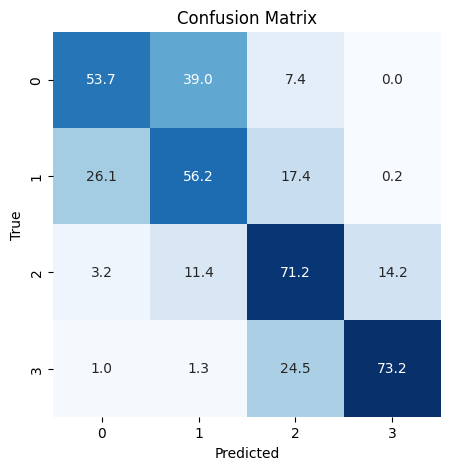

In [23]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Funzione per trovare il file predictions.json
def find_predictions_file(base_path, fold, holdout):
    return os.path.join(base_path, f'fold_{fold}', f'holdout_{holdout}', 'predictions.json')

# Funzione per estrarre tutte le previsioni e i valori reali
def extract_predictions(predictions_path):
    with open(predictions_path, 'r') as file:
        data = json.load(file)
        y_test = data['y_test']
        y_test_pred = data['y_test_pred']
        
        return y_test, y_test_pred

# Funzione principale per ottenere tutte le previsioni di uno specifico modello
def main(model_path, fold, holdout):
    results = []
    
    predictions_path = find_predictions_file(model_path, fold, holdout)
    
    if os.path.exists(predictions_path):
        y_test, y_test_pred = extract_predictions(predictions_path)
        
        for i in range(len(y_test)):
            y_true = y_test[i]
            y_pred = np.argmax(y_test_pred[i])
            results.append({
                'index': i,
                'y_test': y_true,
                'y_test_pred': y_pred
            })
    else:
        print(f"File non trovato: {predictions_path}")
        return pd.DataFrame()

    df = pd.DataFrame(results)
    return df

# Funzione per calcolare accuracy e F1 score
def calculate_metrics(df):
    y_true = df['y_test']
    y_pred = df['y_test_pred']
    
    # Calcolo delle metriche
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')  # Calcolo del F1 score ponderato
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

    return accuracy, f1, qwk

def calculate_cm(df):
    y_true = df['y_test']
    y_pred = df['y_test_pred']

    # Calcolo della matrice di confusione
    conf_matrix = confusion_matrix(y_true, y_pred)
    
    # Normalizzazione della matrice di confusione in percentuale
    conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
    
    # Visualizzazione della matrice di confusione
    plt.figure(figsize=(5, 5))
    sns.heatmap(conf_matrix_percent, annot=True, fmt='.1f', cmap='Blues', cbar=False,
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


# Percorso del modello specifico
model_path = "/Users/edoardoconti/Downloads/results_ordinal_paper/seed94_clm_resnet50_100_[32]_[0.3]_['cloglog']_[True]_QWK_SDG_[0.01]"
#model_path = "/Users/edoardoconti/Downloads/results_ordinal_paper/seed94_resnet50_100_[32]_[0.3]_CCE_SDG_['cdr']"

# Fold e holdout specifici
fold = 5
holdout = 3

# Esegui il processo e ottieni il dataframe
df_results = main(model_path, fold, holdout)

# Visualizza il dataframe risultante
#print(df_results)

accuracy, f1, qwk = calculate_metrics(df_results)
print(f"Accuracy: {accuracy:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"QWK: {qwk:.3f}")

calculate_cm(df_results)

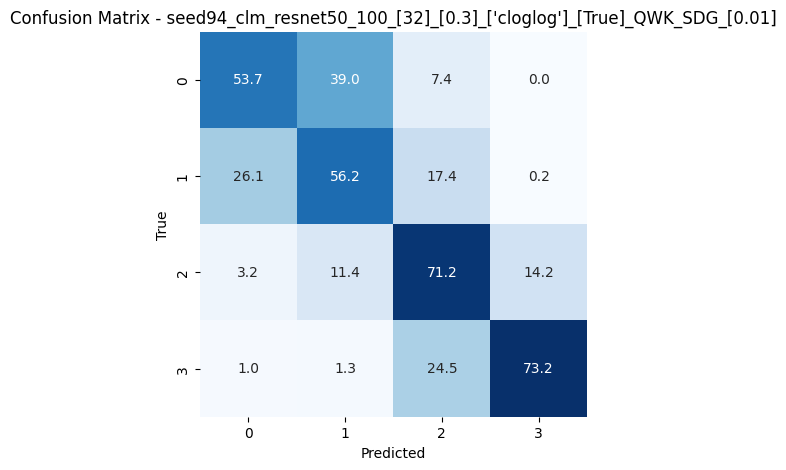

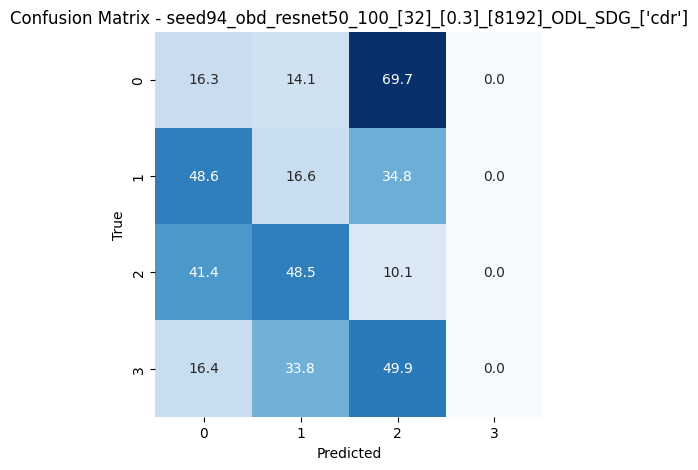

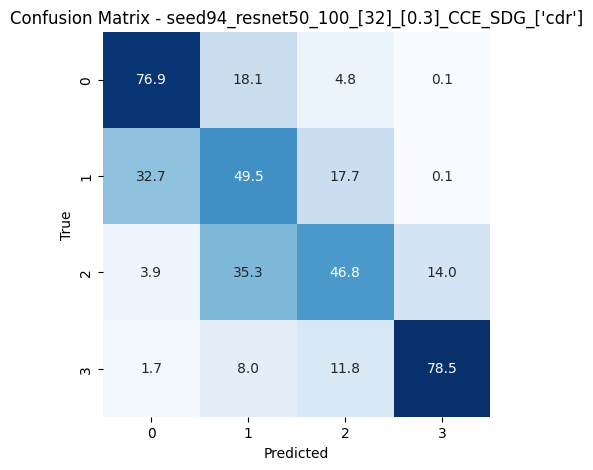

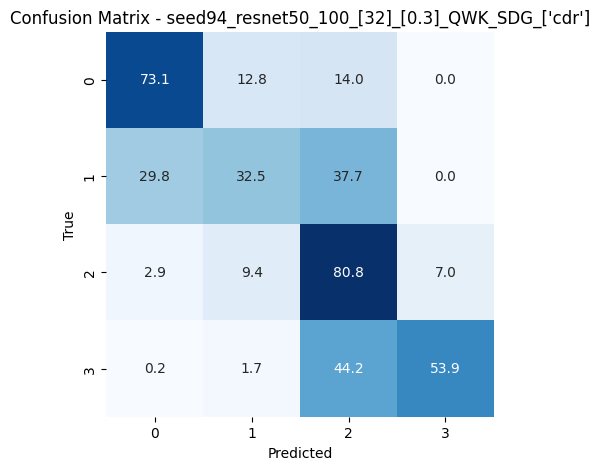

                                               model  accuracy  f1_score  \
3     seed94_resnet50_100_[32]_[0.3]_QWK_SDG_['cdr']  0.655290  0.649260   
2     seed94_resnet50_100_[32]_[0.3]_CCE_SDG_['cdr']  0.628443  0.635294   
0  seed94_clm_resnet50_100_[32]_[0.3]_['cloglog']...  0.611308  0.621747   
1  seed94_obd_resnet50_100_[32]_[0.3]_[8192]_ODL_...  0.130003  0.130437   

        qwk  
3  0.740487  
2  0.763487  
0  0.749165  
1 -0.288265  


In [3]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Funzione per trovare il file predictions.json
def find_predictions_file(base_path, fold, holdout):
    return os.path.join(base_path, f'fold_{fold}', f'holdout_{holdout}', 'predictions.json')

# Funzione per estrarre tutte le previsioni e i valori reali
def extract_predictions(predictions_path):
    with open(predictions_path, 'r') as file:
        data = json.load(file)
        y_test = data['y_test']
        y_test_pred = data['y_test_pred']
        
        return y_test, y_test_pred

# Funzione principale per ottenere tutte le previsioni di uno specifico modello
def main(model_path, fold, holdout):
    results = []
    
    predictions_path = find_predictions_file(model_path, fold, holdout)
    
    if os.path.exists(predictions_path):
        y_test, y_test_pred = extract_predictions(predictions_path)
        
        for i in range(len(y_test)):
            y_true = y_test[i]
            y_pred = np.argmax(y_test_pred[i])
            results.append({
                'index': i,
                'y_test': y_true,
                'y_test_pred': y_pred
            })
    else:
        print(f"File non trovato: {predictions_path}")
        return pd.DataFrame()

    df = pd.DataFrame(results)
    return df

# Funzione per calcolare accuracy, F1 score e QWK
def calculate_metrics(df):
    y_true = df['y_test']
    y_pred = df['y_test_pred']
    
    # Calcolo delle metriche
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')  # Calcolo del F1 score ponderato
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

    return accuracy, f1, qwk

# Funzione per calcolare e visualizzare la matrice di confusione
def calculate_cm(df, model_name):
    y_true = df['y_test']
    y_pred = df['y_test_pred']

    # Calcolo della matrice di confusione
    conf_matrix = confusion_matrix(y_true, y_pred)
    
    # Normalizzazione della matrice di confusione in percentuale
    conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
    
    # Visualizzazione della matrice di confusione
    plt.figure(figsize=(5, 5))
    sns.heatmap(conf_matrix_percent, annot=True, fmt='.1f', cmap='Blues', cbar=False,
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# Funzione per eseguire tutto il processo su più modelli
def process_multiple_models(model_paths, fold, holdout):
    metrics_list = []
    
    for model_path in model_paths:
        # Ottieni il nome del modello dal percorso per facilitare la lettura dei risultati
        model_name = os.path.basename(model_path)
        
        # Esegui il processo per ottenere il dataframe dei risultati
        df_results = main(model_path, fold, holdout)
        
        if not df_results.empty:
            # Calcola le metriche per il modello corrente
            accuracy, f1, qwk = calculate_metrics(df_results)
            
            # Aggiungi i risultati in una lista
            metrics_list.append({
                'model': model_name,
                'accuracy': accuracy,
                'f1_score': f1,
                'qwk': qwk
            })
            
            # Visualizza la matrice di confusione per il modello corrente
            calculate_cm(df_results, model_name)
        else:
            print(f"Impossibile elaborare il modello: {model_name}. File predictions.json non trovato.")

    # Crea un DataFrame con i risultati
    df_metrics = pd.DataFrame(metrics_list)
    return df_metrics

# Percorsi dei modelli
model_paths = [
    "/Users/edoardoconti/Downloads/results_ordinal_paper/seed94_clm_resnet50_100_[32]_[0.3]_['cloglog']_[True]_QWK_SDG_[0.01]",
    "/Users/edoardoconti/Downloads/results_ordinal_paper/seed94_obd_resnet50_100_[32]_[0.3]_[8192]_ODL_SDG_['cdr']",
    "/Users/edoardoconti/Downloads/results_ordinal_paper/seed94_resnet50_100_[32]_[0.3]_CCE_SDG_['cdr']",
    "/Users/edoardoconti/Downloads/results_ordinal_paper/seed94_resnet50_100_[32]_[0.3]_QWK_SDG_['cdr']"
]

# Fold e holdout specifici
fold = 5
holdout = 3

# Esegui il processo per tutti i modelli e ottieni le metriche
df_metrics = process_multiple_models(model_paths, fold, holdout)

# Visualizza il DataFrame con le metriche per tutti i modelli
print(df_metrics.sort_values(by=['f1_score', 'qwk'], ascending=False))